In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
# Keep only numeric columns
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Handle missing values (simple approach)
df_numeric = df_numeric.dropna()

df_numeric.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
from sklearn.cluster import KMeans

# Choose number of clusters
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)

# Fit model
kmeans.fit(df_numeric)

# Assign cluster labels
df_numeric['Cluster'] = kmeans.labels_

df_numeric.head()

,sepal_length,sepal_width,petal_length,petal_width,Cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


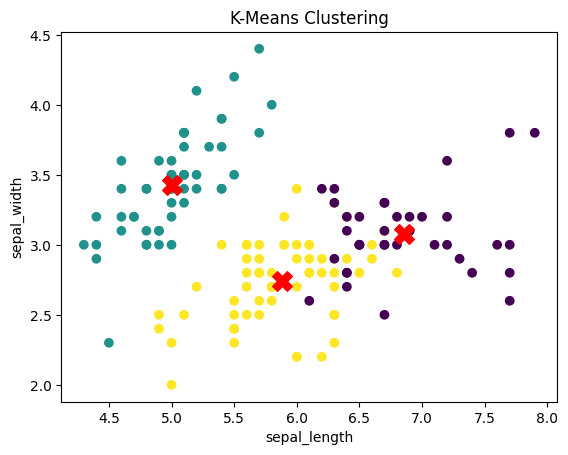

In [4]:
import matplotlib.pyplot as plt

# Pick two columns for visualization
x_col = df_numeric.columns[0]
y_col = df_numeric.columns[1]

plt.scatter(df_numeric[x_col], df_numeric[y_col], c=df_numeric['Cluster'])

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='X', s=200)

plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title("K-Means Clustering")
plt.show()